# S4oP vs. Unstructured

## Seed 7

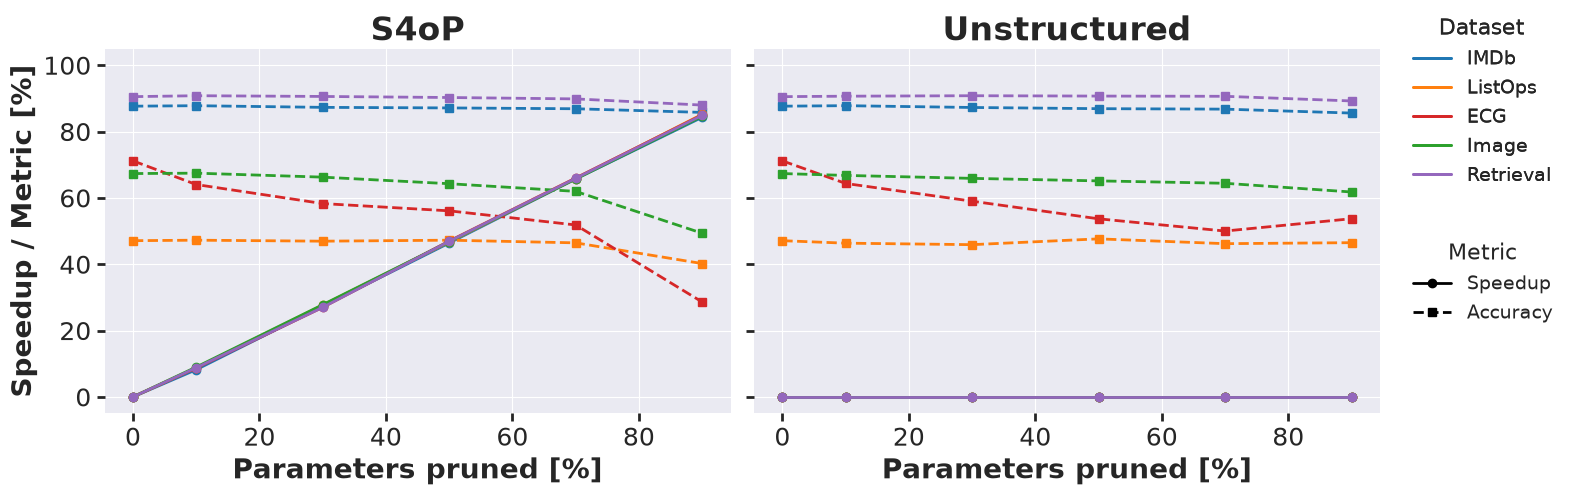

In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Punti sull'asse x
pruning_rates = [0, 10, 30, 50, 70, 90]

datasets = ["imdb", "listops", "ecg", "image", "retrieval"]
methods  = ["s4op", "unstructured"]

# Struttura: results[metrica][metodo][dataset] = lista di valori
results = {
    "accuracy": {
        "s4op": {
            "imdb":      [87.656, 87.80, 87.30, 87.13, 86.88, 85.78],
            "listops":   [47.100, 47.25, 46.95, 47.25, 46.45, 40.20],
            "ecg":       [71.170, 64.03, 58.29, 56.10, 51.84, 28.62],
            "image":     [67.340, 67.46, 66.26, 64.28, 61.97, 49.35],
            "retrieval": [90.532, 90.81, 90.59, 90.27, 89.85, 87.99],
        },
        "unstructured": {
            "imdb":      [87.656, 87.808, 87.264, 86.904, 86.764, 85.580],
            "listops":   [47.100, 46.350, 45.900, 47.650, 46.200, 46.500],
            "ecg":       [71.170, 64.358, 59.008, 53.694, 50.007, 53.726],
            "image":     [67.340, 66.780, 65.890, 65.130, 64.410, 61.780],
            "retrieval": [90.532, 90.669, 90.807, 90.704, 90.635, 89.233],
        },
    },
    "speedup": {
        "s4op": {
            "imdb":      [0, 8.2, 27.3, 46.4, 65.7, 84.3],
            "listops":   [0, 8.8, 27.7, 46.7, 65.8, 85.2],
            "ecg":       [0, 8.7, 27.0, 47.0, 66.0, 85.0],
            "image":     [0, 9.0, 27.8, 46.8, 65.7, 84.6],
            "retrieval": [0, 8.8, 27.0, 46.9, 65.9, 84.9],
        },
        "unstructured": {
            "imdb":      [0, 0, 0, 0, 0, 0],
            "listops":   [0, 0, 0, 0, 0, 0],
            "ecg":       [0, 0, 0, 0, 0, 0],
            "image":     [0, 0, 0, 0, 0, 0],
            "retrieval": [0, 0, 0, 0, 0, 0],
        },
    },
}

dataset_colors = {
    "imdb": "tab:blue",
    "listops": "tab:orange",
    "ecg": "tab:red",
    "image": "tab:green",
    "retrieval": "tab:purple",
}
dataset_labels = {
    "imdb": "IMDb", "listops": "ListOps", "ecg": "ECG",
    "image": "Image", "retrieval": "Retrieval",
}
method_titles = {"s4op": "S4oP", "unstructured": "Unstructured"}

plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(1, len(methods), figsize=(14, 5), sharey=True)
if len(methods) == 1:
    axes = [axes]

for ax, method in zip(axes, methods):
    for dataset in datasets:
        color = dataset_colors[dataset]

        speed = results["speedup"][method][dataset]
        acc = results["accuracy"][method][dataset]

        # SPEEDUP (linea piena) — solo se i dati combaciano con l'asse
        if len(speed) == len(pruning_rates):
            ax.plot(pruning_rates, speed, marker='o', linewidth=2,
                    color=color, linestyle='-')

        # ACCURACY (tratteggiata) — solo se i dati combaciano con l'asse
        if len(acc) == len(pruning_rates):
            ax.plot(pruning_rates, acc, marker='s', linewidth=2,
                    color=color, linestyle='--')

    ax.set_title(method_titles[method], fontsize=24, fontweight='bold')
    ax.set_xlabel("Parameters pruned [%]", fontsize=20, fontweight='bold')
    ax.set_ylim(-5, 105)
    ax.tick_params(axis='both', which='major', labelsize=18, length=6, width=2)
    ax.grid(True)

# ylabel solo sul primo subplot (sharey nasconde gli altri)
axes[0].set_ylabel("Speedup / Metric [%]", fontsize=20, fontweight='bold')

# Legenda dataset (colori)
dataset_handles = [
    Line2D([0], [0], color=dataset_colors[d], lw=2, label=dataset_labels[d])
    for d in datasets
]
# Legenda stile linea (speedup vs accuracy)
style_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle='-',  marker='o', label='Speedup'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', marker='s', label='Accuracy'),
]

leg1 = fig.legend(handles=dataset_handles, title="Dataset",
                  loc='upper left', bbox_to_anchor=(1.0, 1.0),
                  fontsize=14, title_fontsize=16)
fig.legend(handles=style_handles, title="Metric",
           loc='upper left', bbox_to_anchor=(1.0, 0.55),
           fontsize=14, title_fontsize=16)
fig.add_artist(leg1)  # mantieni entrambe le legende
fig.tight_layout()
plt.show()

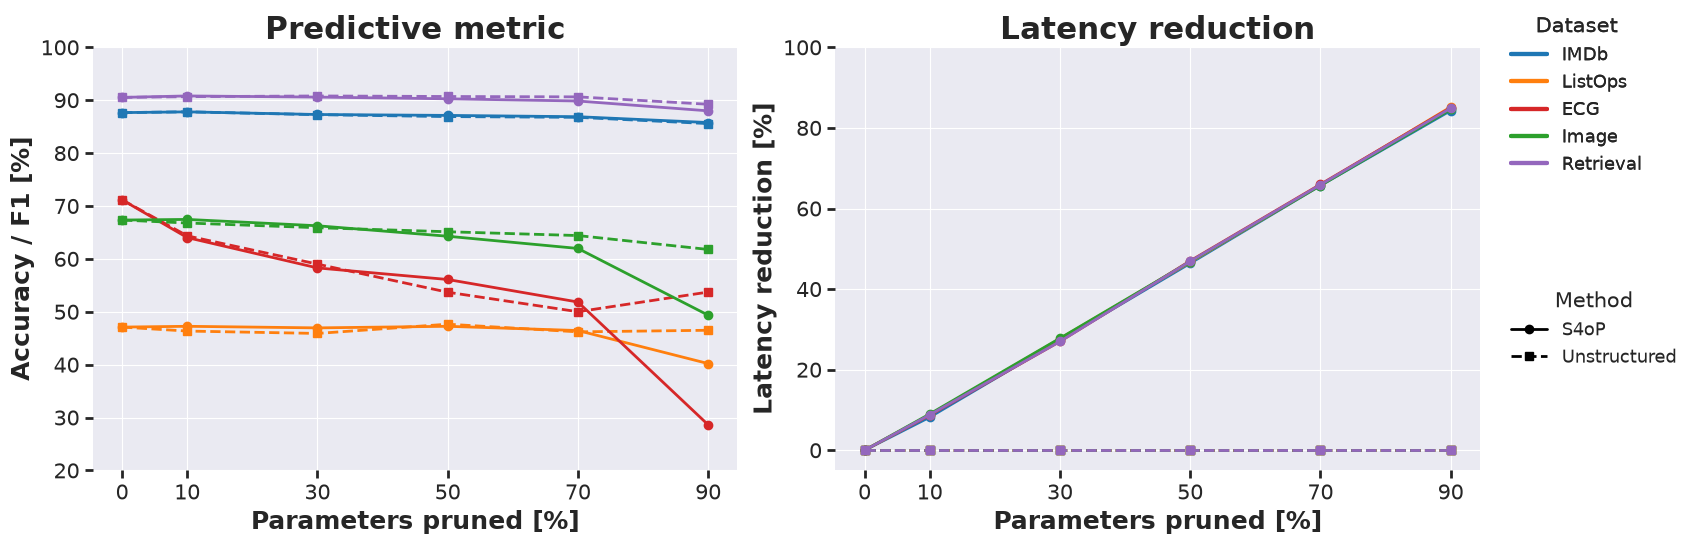

In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pruning_rates = [0, 10, 30, 50, 70, 90]
datasets = ["imdb", "listops", "ecg", "image", "retrieval"]
methods  = ["s4op", "unstructured"]

results = {
    "accuracy": {
        "s4op": {
            "imdb":      [87.656, 87.80, 87.30, 87.13, 86.88, 85.78],
            "listops":   [47.100, 47.25, 46.95, 47.25, 46.45, 40.20],
            "ecg":       [71.170, 64.03, 58.29, 56.10, 51.84, 28.62],
            "image":     [67.340, 67.46, 66.26, 64.28, 61.97, 49.35],
            "retrieval": [90.532, 90.81, 90.59, 90.27, 89.85, 87.99],
        },
        "unstructured": {
            "imdb":      [87.656, 87.808, 87.264, 86.904, 86.764, 85.580],
            "listops":   [47.100, 46.350, 45.900, 47.650, 46.200, 46.500],
            "ecg":       [71.170, 64.358, 59.008, 53.694, 50.007, 53.726],
            "image":     [67.340, 66.780, 65.890, 65.130, 64.410, 61.780],
            "retrieval": [90.532, 90.669, 90.807, 90.704, 90.635, 89.233],
        },
    },
    "speedup": {
        "s4op": {
            "imdb":      [0, 8.2, 27.3, 46.4, 65.7, 84.3],
            "listops":   [0, 8.8, 27.7, 46.7, 65.8, 85.2],
            "ecg":       [0, 8.7, 27.0, 47.0, 66.0, 85.0],
            "image":     [0, 9.0, 27.8, 46.8, 65.7, 84.6],
            "retrieval": [0, 8.8, 27.0, 46.9, 65.9, 84.9],
        },
        "unstructured": {
            "imdb":      [0, 0, 0, 0, 0, 0],
            "listops":   [0, 0, 0, 0, 0, 0],
            "ecg":       [0, 0, 0, 0, 0, 0],
            "image":     [0, 0, 0, 0, 0, 0],
            "retrieval": [0, 0, 0, 0, 0, 0],
        },
    },
}

dataset_colors = {
    "imdb": "tab:blue", "listops": "tab:orange", "ecg": "tab:red",
    "image": "tab:green", "retrieval": "tab:purple",
}
dataset_labels = {
    "imdb": "IMDb", "listops": "ListOps", "ecg": "ECG",
    "image": "Image", "retrieval": "Retrieval",
}
# stile linea = metodo
method_styles  = {"s4op": "-",  "unstructured": "--"}
method_markers = {"s4op": "o",  "unstructured": "s"}
method_labels  = {"s4op": "S4oP", "unstructured": "Unstructured"}

metrics = ["accuracy", "speedup"]
metric_titles = {"accuracy": "Predictive metric", "speedup": "Latency reduction"}
metric_ylabels = {"accuracy": "Accuracy / F1 [%]", "speedup": "Latency reduction [%]"}
metric_ylims  = {"accuracy": (20, 100), "speedup": (-5, 100)}

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(metrics), figsize=(15, 5.5))

for ax, metric in zip(axes, metrics):
    for dataset in datasets:
        for method in methods:
            y = results[metric][method][dataset]
            if len(y) != len(pruning_rates):
                continue
            ax.plot(pruning_rates, y,
                    marker=method_markers[method],
                    linestyle=method_styles[method],
                    linewidth=2, color=dataset_colors[dataset])

    ax.set_title(metric_titles[metric], fontsize=22, fontweight='bold')
    ax.set_xlabel("Parameters pruned [%]", fontsize=18, fontweight='bold')
    ax.set_ylabel(metric_ylabels[metric], fontsize=18, fontweight='bold')
    ax.set_ylim(*metric_ylims[metric])
    ax.set_xticks(pruning_rates)
    ax.tick_params(axis='both', which='major', labelsize=15, length=6, width=2)
    ax.grid(True)

dataset_handles = [Line2D([0], [0], color=dataset_colors[d], lw=3, label=dataset_labels[d])
                   for d in datasets]
method_handles = [Line2D([0], [0], color='black', lw=2,
                         linestyle=method_styles[m], marker=method_markers[m],
                         label=method_labels[m]) for m in methods]

leg1 = fig.legend(handles=dataset_handles, title="Dataset", loc='upper left',
                  bbox_to_anchor=(1.0, 1.0), fontsize=13, title_fontsize=15)
fig.legend(handles=method_handles, title="Method", loc='upper left',
           bbox_to_anchor=(1.0, 0.5), fontsize=13, title_fontsize=15)
fig.add_artist(leg1)

fig.tight_layout()
plt.show()

## Risultati aggregati

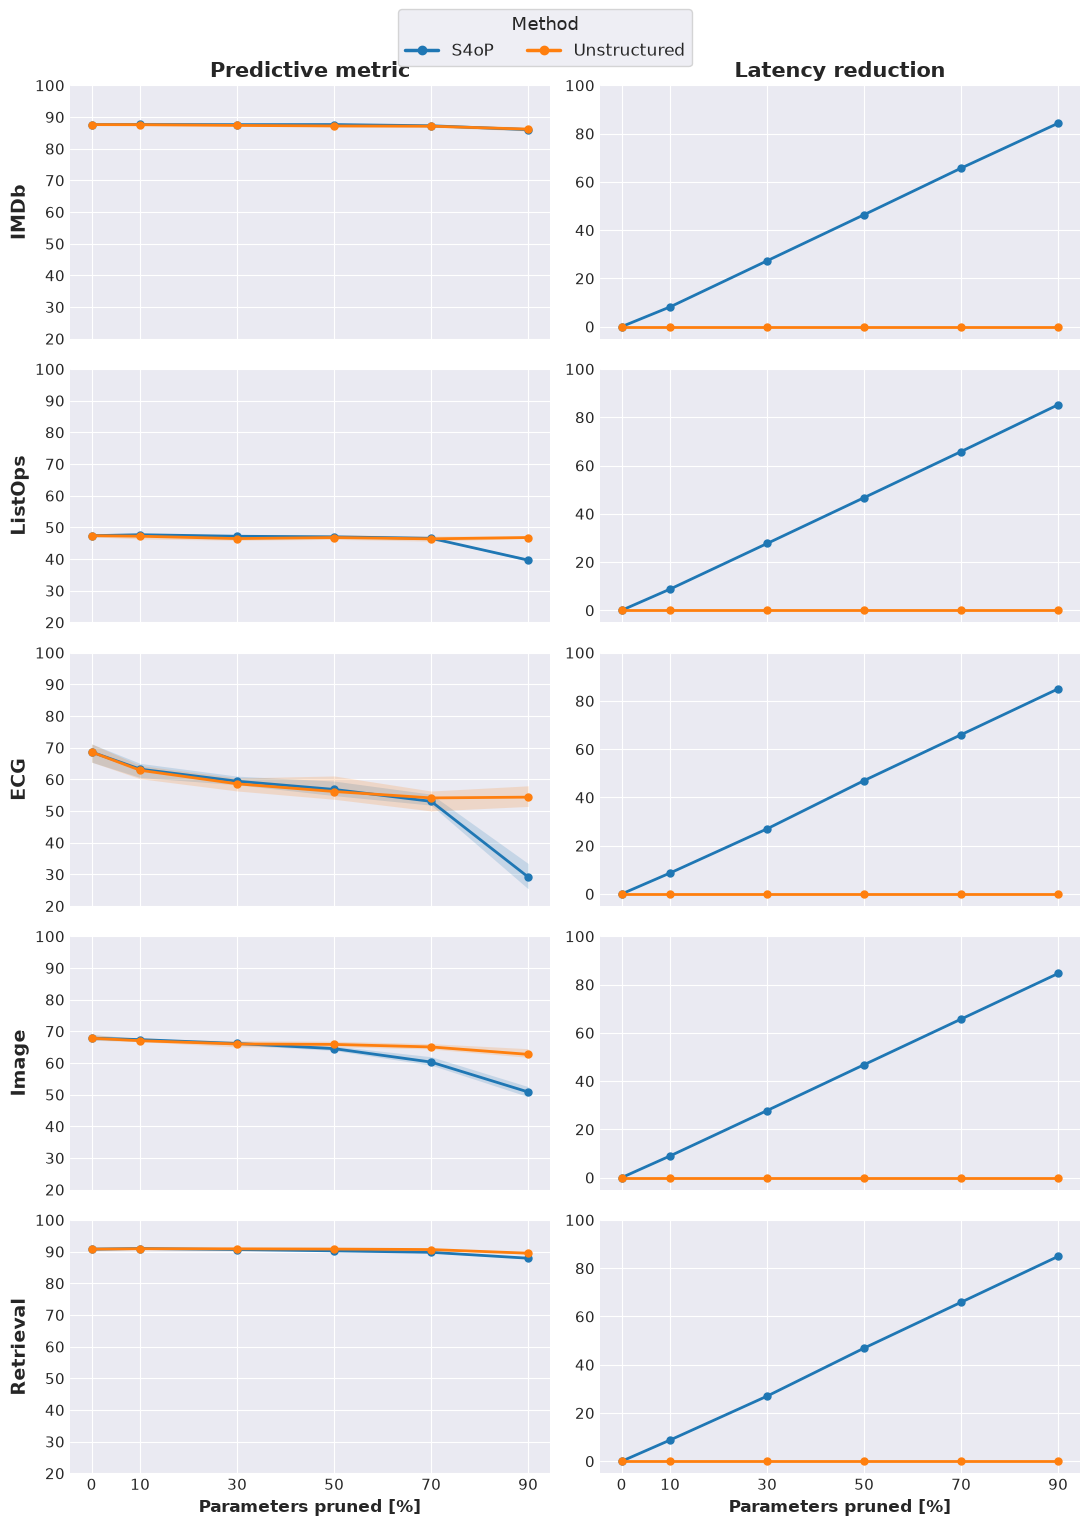


=== ACCURACY — media [min-max] su s4op/unstructured ===
dataset     method                      0%             10%             30%             50%             70%             90%
--------------------------------------------------------------------------------------------------------------------------
imdb        s4op           87.6[87.3,87.8] 87.6[87.5,87.8] 87.6[87.3,87.8] 87.6[87.1,88.0] 87.2[86.9,87.5] 86.0[85.6,86.7]   (n=3)
imdb        unstructured   87.6[87.3,87.8] 87.6[87.1,87.8] 87.3[87.3,87.4] 87.2[86.9,87.4] 87.1[86.8,87.5] 86.2[85.6,86.9]   (n=3)
listops     s4op           47.4[47.0,48.0] 47.7[47.2,48.0] 47.2[47.0,47.4] 47.0[46.5,47.2] 46.5[46.5,46.6] 39.6[39.3,40.2]   (n=3)
listops     unstructured   47.4[47.0,48.0] 47.2[46.4,48.1] 46.4[45.9,47.5] 46.8[46.2,47.6] 46.4[45.6,47.2] 46.8[46.5,47.2]   (n=3)
ecg         s4op           68.6[65.4,71.2] 63.2[60.6,65.0] 59.4[58.3,61.0] 56.8[54.9,59.5] 53.0[51.8,55.3] 29.2[25.4,33.4]   (n=3)
ecg         unstructured   68.6[65.4,71.2]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
 
# ---------------------------------------------------------------------------
# ASSE X
# ---------------------------------------------------------------------------
pruning_rates = [0, 10, 30, 50, 70, 90]
 
datasets = ["imdb", "listops", "ecg", "image", "retrieval"]
methods  = ["s4op", "unstructured"]
 
# ---------------------------------------------------------------------------
# DATI
#   Ogni entry e' una lista di run (una lista per seed).
#   SEED 1 = dati gia' ottenuti. SEED 2/3 = placeholder (None), da riempire.
#   Usare None per i singoli punti mancanti (es. livelli non ancora testati).
# ---------------------------------------------------------------------------
N = len(pruning_rates)
 
results = {
    # =======================================================================
    # ACCURACY / F1  [%]
    # =======================================================================
    "accuracy": {
        "s4op": {
            "imdb": [
                [87.656, 87.80, 87.30, 87.13, 86.88, 85.78],  
                [87.844, 87.64, 87.68, 87.67, 87.31, 85.64],               
                [87.292, 87.47, 87.79, 88.04, 87.52, 86.65],                              
            ],
            "listops": [
                [47.100, 47.25, 46.95, 47.25, 46.45, 40.20],  
                [47.000, 48.00, 47.25, 47.20, 46.50, 39.45], 
                [48.000, 47.75, 47.35, 46.55, 46.65, 39.30], 
            ],
            "ecg": [
                [71.170, 64.03, 58.29, 56.10, 51.84, 28.62],   
                [69.231, 60.57, 58.91, 54.86, 51.98, 33.42], 
                [65.414, 65.03, 61.00, 59.45, 55.31, 25.42], 
            ],
            "image": [
                [67.340, 67.46, 66.26, 64.28, 61.97, 49.35],  
                [67.170, 66.92, 65.68, 65.35, 59.31, 50.63], 
                [68.970, 67.75, 66.53, 63.94, 59.55, 52.53], 
            ],
            "retrieval": [
                [90.532, 90.81, 90.59, 90.27, 89.85, 87.99],  
                [90.480, 90.91, 90.68, 90.29, 89.85, 87.81], 
                [91.329, 91.20, 90.65, 90.17, 89.62, 87.93], 
            ],
        },
        "unstructured": {
            "imdb": [
                [87.656, 87.808, 87.264, 86.904, 86.764, 85.580], 
                [87.844, 87.840, 87.380, 87.220, 87.020, 86.000], 
                [87.292, 87.130, 87.390, 87.390, 87.520, 86.900], 
            ],
            "listops": [
                [47.100, 46.350, 45.900, 47.650, 46.200, 46.500],  
                [47.000, 47.100, 45.950, 46.200, 45.650, 46.600], 
                [48.000, 48.150, 47.500, 46.500, 47.250, 47.250], 
            ],
            "ecg": [
                [71.170, 64.358, 59.008, 53.694, 50.007, 53.726], 
                [69.231, 64.019, 56.315, 53.699, 56.070, 57.950], 
                [65.414, 60.185, 60.423, 61.060, 56.304, 51.441], 
            ],
            "image": [
                [67.340, 66.780, 65.890, 65.130, 64.410, 61.780], 
                [67.170, 66.730, 65.060, 65.580, 64.660, 61.870], 
                [68.970, 67.570, 67.040, 66.860, 66.100, 64.510], 
            ],
            "retrieval": [
                [90.532, 90.669, 90.807, 90.704, 90.635, 89.233], 
                [90.480, 90.853, 90.623, 90.750, 90.491, 89.367], 
                [91.329, 91.185, 91.214, 90.950, 90.824, 89.878], 
            ],
        },
    },
 
    # =======================================================================
    # LATENCY REDUCTION  [%]   (speedup espresso come riduzione percentuale)
    #   S4oP: compressione strutturale reale -> riduzione > 0
    #   Unstructured: masking denso-con-zeri -> nessuna riduzione (~0)
    #   NB: i valori unstructured vanno MISURATI col profiling, non assunti.
    #       Finche' non profilati, lasciarli come placeholder (EMPTY).
    # =======================================================================
    "speedup": {
        "s4op": {
            "imdb": [
                [0, 8.2, 27.3, 46.4, 65.7, 84.3],
                [0, 8.2, 27.3, 46.4, 65.7, 84.3],
                [0, 8.2, 27.3, 46.4, 65.7, 84.3], 
            ],
            "listops": [
                [0, 8.8, 27.7, 46.7, 65.8, 85.2],
                [0, 8.8, 27.7, 46.7, 65.8, 85.2],
                [0, 8.8, 27.7, 46.7, 65.8, 85.2], 
            ],
            "ecg": [
                [0, 8.7, 27.0, 47.0, 66.0, 85.0], 
                [0, 8.7, 27.0, 47.0, 66.0, 85.0], 
                [0, 8.7, 27.0, 47.0, 66.0, 85.0],
            ],
            "image": [
                [0, 9.0, 27.8, 46.8, 65.7, 84.6],   
                [0, 9.0, 27.8, 46.8, 65.7, 84.6], 
                [0, 9.0, 27.8, 46.8, 65.7, 84.6],  
            ],
            "retrieval": [
                [0, 8.8, 27.0, 46.9, 65.9, 84.9],  
                [0, 8.8, 27.0, 46.9, 65.9, 84.9],
                [0, 8.8, 27.0, 46.9, 65.9, 84.9],
            ],
        },
        "unstructured": {
            # placeholder: da riempire con i profili reali (attesi ~0 +/- rumore)
            "imdb":      [[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0]],
            "listops":   [[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0]],
            "ecg":       [[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0]],
            "image":     [[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0]],
            "retrieval": [[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0]],
        },
    },
}
 
# ---------------------------------------------------------------------------
# STILE
#   colore = METODO (il dataset e' identificato dal titolo di riga)
# ---------------------------------------------------------------------------
method_colors = {"s4op": "tab:blue", "unstructured": "tab:orange"}
method_labels = {"s4op": "S4oP", "unstructured": "Unstructured"}
 
dataset_labels = {
    "imdb": "IMDb", "listops": "ListOps", "ecg": "ECG",
    "image": "Image", "retrieval": "Retrieval",
}
 
metrics = ["accuracy", "speedup"]
metric_titles = {"accuracy": "Predictive metric", "speedup": "Latency reduction"}
metric_ylabels = {"accuracy": "Accuracy / F1 [%]", "speedup": "Latency reduction [%]"}
metric_ylims  = {"accuracy": (20, 100), "speedup": (-5, 100)}
 
# ---------------------------------------------------------------------------
# AGGREGAZIONE MULTI-SEED
# ---------------------------------------------------------------------------
def mean_band(list_of_runs):
    """Da [[seed1],[seed2],[seed3]] -> (media, min, max) per punto, ignorando i None."""
    arr = np.array(list_of_runs, dtype=float)   # None -> nan ; shape [n_seed, n_pts]
    if arr.size == 0:
        n = len(pruning_rates)
        return (np.full(n, np.nan),) * 3
    with np.errstate(all="ignore"):
        mean = np.nanmean(arr, axis=0)
        lo   = np.nanmin(arr, axis=0)
        hi   = np.nanmax(arr, axis=0)
    return mean, lo, hi
 
def n_valid_seeds(list_of_runs):
    return sum(any(v is not None for v in run) for run in list_of_runs)
 
# ---------------------------------------------------------------------------
# PLOT: griglia dataset (righe) x metrica (colonne)
# ---------------------------------------------------------------------------
plt.style.use("seaborn-v0_8-darkgrid")
nrows, ncols = len(datasets), len(metrics)
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(11, 3.0 * nrows),
                         squeeze=False, sharex=True)
 
x = np.array(pruning_rates)
 
for i, dataset in enumerate(datasets):
    for j, metric in enumerate(metrics):
        ax = axes[i][j]
        for method in methods:
            runs = results[metric][method][dataset]
            mean, lo, hi = mean_band(runs)
            if np.all(np.isnan(mean)):
                continue
            valid = ~np.isnan(mean)
            c = method_colors[method]
            # banda min-max (spessore 0 se un solo seed -> invisibile, corretto)
            ax.fill_between(x[valid], lo[valid], hi[valid],
                            color=c, alpha=0.18, linewidth=0)
            # linea media
            ax.plot(x[valid], mean[valid], marker="o", markersize=5,
                    linewidth=2, color=c, label=method_labels[method])
 
        # etichette assi/titoli solo dove serve
        if j == 0:
            ax.set_ylabel(dataset_labels[dataset], fontsize=14, fontweight="bold")
        if i == 0:
            ax.set_title(metric_titles[metric], fontsize=15, fontweight="bold")
        if i == nrows - 1:
            ax.set_xlabel("Parameters pruned [%]", fontsize=12, fontweight="bold")
 
        ax.set_ylim(*metric_ylims[metric])
        ax.set_xticks(pruning_rates)
        ax.tick_params(axis="both", which="major", labelsize=11)
        ax.grid(True)
 
# una sola legenda (i colori-metodo sono identici in tutti i riquadri)
handles = [Line2D([0], [0], color=method_colors[m], lw=2.5, marker="o",
                  label=method_labels[m]) for m in methods]
fig.legend(handles=handles, title="Method", loc="upper center",
           ncol=len(methods), bbox_to_anchor=(0.5, 1.02),
           fontsize=12, title_fontsize=13, frameon=True)
 
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig("pruning_comparison_grid.png", dpi=200, bbox_inches="tight")
plt.show()
 
# ---------------------------------------------------------------------------
# TABELLA DI SUPPORTO (media, con range min-max dove n>1) - allineata
# ---------------------------------------------------------------------------
def print_table(metric, show_range=True):
    COLW = 16 if show_range else 8
    print(f"\n=== {metric.upper()} — media [min-max] su {'/'.join(methods)} ===")
    header = f"{'dataset':<12}{'method':<14}" + "".join(
        f"{str(r) + '%':>{COLW}}" for r in pruning_rates)
    print(header)
    print("-" * len(header))
    for dataset in datasets:
        for method in methods:
            runs = results[metric][method][dataset]
            mean, lo, hi = mean_band(runs)
            ns = n_valid_seeds(runs)
            cells = ""
            for m, l, h in zip(mean, lo, hi):
                if np.isnan(m):
                    cells += f"{'--':>{COLW}}"
                elif show_range and ns > 1 and (h - l) > 0.05:
                    cells += f"{f'{m:.1f}[{l:.1f},{h:.1f}]':>{COLW}}"
                else:
                    cells += f"{m:>{COLW}.1f}"
            print(f"{dataset:<12}{method:<14}{cells}   (n={ns})")
 
if __name__ == "__main__":
    for metric in metrics:
        print_table(metric)